0:	learn: 1039.8267788	test: 1034.9102633	best: 1034.9102633 (0)	total: 6.95ms	remaining: 6.94s
100:	learn: 23.8764416	test: 24.0048474	best: 24.0048474 (100)	total: 329ms	remaining: 2.93s
200:	learn: 16.1477172	test: 16.3460970	best: 16.3460970 (200)	total: 668ms	remaining: 2.65s
300:	learn: 12.8070379	test: 13.0130733	best: 13.0130733 (300)	total: 1.01s	remaining: 2.34s
400:	learn: 10.6366276	test: 10.8589798	best: 10.8589798 (400)	total: 1.33s	remaining: 1.99s
500:	learn: 9.1208948	test: 9.3526410	best: 9.3526410 (500)	total: 1.65s	remaining: 1.64s
600:	learn: 7.9596269	test: 8.1874669	best: 8.1874669 (600)	total: 1.96s	remaining: 1.3s
700:	learn: 7.1074930	test: 7.3231213	best: 7.3231213 (700)	total: 2.28s	remaining: 974ms
800:	learn: 6.3884910	test: 6.6184840	best: 6.6184840 (800)	total: 2.61s	remaining: 649ms
900:	learn: 5.7564295	test: 5.9842945	best: 5.9842945 (900)	total: 2.93s	remaining: 322ms
999:	learn: 5.2551772	test: 5.4844621	best: 5.4844621 (999)	total: 3.25s	remaining:

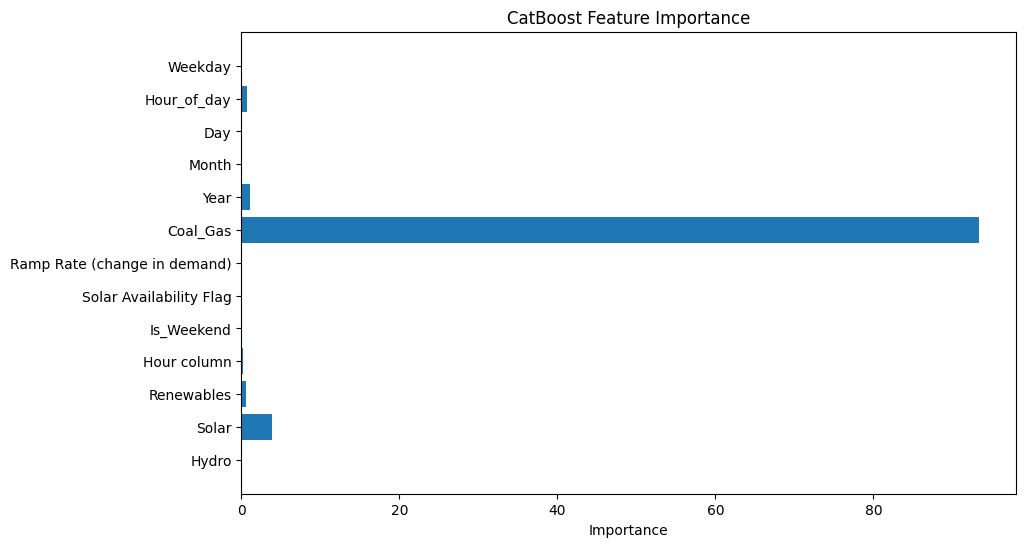

In [3]:
# -----------------------------
# CatBoost Regression on Preprocessed Haryana Dataset
# -----------------------------

import pandas as pd
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Load preprocessed dataset
df = pd.read_csv("haryana_hourly_generation_preprocessed.csv")

# Separate features and target
X = df.drop(columns=['Demand_MWh'])
y = df['Demand_MWh']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize CatBoost Regressor
model = CatBoostRegressor(
    iterations=1000,        # number of boosting rounds
    learning_rate=0.1,
    depth=6,
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

# Train the model
model.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

# Predictions
y_pred = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n✅ CatBoost Regression Results:")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")

# Optional: feature importance
import matplotlib.pyplot as plt

feature_importances = model.get_feature_importance()
plt.figure(figsize=(10,6))
plt.barh(X.columns, feature_importances)
plt.xlabel("Importance")
plt.title("CatBoost Feature Importance")
plt.show()


0:	learn: 1044.3369339	test: 1073.5738724	best: 1073.5738724 (0)	total: 7.99ms	remaining: 7.98s
100:	learn: 32.2877163	test: 43.6778568	best: 43.6778568 (100)	total: 368ms	remaining: 3.27s
200:	learn: 21.7149184	test: 35.2335830	best: 35.2318955 (198)	total: 695ms	remaining: 2.76s
300:	learn: 16.7736743	test: 33.0378895	best: 33.0378895 (300)	total: 1.09s	remaining: 2.54s
400:	learn: 13.7939430	test: 31.5834283	best: 31.5401575 (395)	total: 1.47s	remaining: 2.19s
500:	learn: 11.7171165	test: 30.7362205	best: 30.6947445 (490)	total: 1.84s	remaining: 1.83s
600:	learn: 10.1642631	test: 30.0806738	best: 30.0750094 (569)	total: 2.21s	remaining: 1.47s
700:	learn: 8.9835149	test: 29.6892605	best: 29.6892605 (700)	total: 2.58s	remaining: 1.1s
800:	learn: 8.0215639	test: 29.5197635	best: 29.4801921 (778)	total: 2.97s	remaining: 738ms
900:	learn: 7.3014036	test: 29.3813449	best: 29.3424975 (893)	total: 3.33s	remaining: 366ms
999:	learn: 6.6992297	test: 29.2626895	best: 29.1789753 (998)	total: 3.

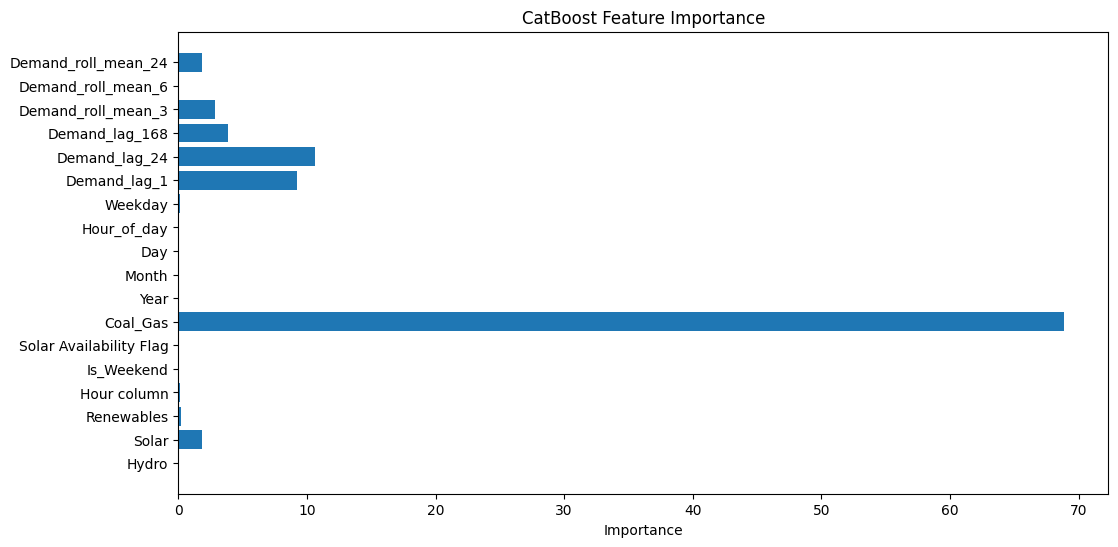

In [4]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv("haryana_hourly_generation_preprocessed.csv")

# Sort by time (assuming 'Year', 'Month', 'Day', 'Hour_of_day' exist)
df = df.sort_values(by=['Year', 'Month', 'Day', 'Hour_of_day']).reset_index(drop=True)

# -----------------------------
# Create lag features
# -----------------------------
lags = [1, 24, 168]  # 1 hour, 1 day, 1 week
for lag in lags:
    df[f'Demand_lag_{lag}'] = df['Demand_MWh'].shift(lag)

# -----------------------------
# Create rolling mean features
# -----------------------------
windows = [3, 6, 24]  # rolling windows in hours
for window in windows:
    df[f'Demand_roll_mean_{window}'] = df['Demand_MWh'].shift(1).rolling(window=window).mean()

# Drop rows with NaNs created by lag/rolling
df = df.dropna().reset_index(drop=True)

# -----------------------------
# Features and target
# -----------------------------
target = 'Demand_MWh'
drop_cols = ['Demand_MWh', 'Ramp Rate (change in demand)']  # drop target and derived feature
X = df.drop(columns=drop_cols)
y = df[target]

# -----------------------------
# Time-based train-test split
# -----------------------------
train_size = 0.8
train_index = int(len(df) * train_size)

X_train, X_test = X.iloc[:train_index], X.iloc[train_index:]
y_train, y_test = y.iloc[:train_index], y.iloc[train_index:]

# -----------------------------
# CatBoost Regressor
# -----------------------------
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

# Train
model.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

# -----------------------------
# Predictions and evaluation
# -----------------------------
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n✅ CatBoost Regression Results with Lag & Rolling Features:")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")

# -----------------------------
# Feature importance
# -----------------------------
feature_importances = model.get_feature_importance()
plt.figure(figsize=(12,6))
plt.barh(X.columns, feature_importances)
plt.xlabel("Importance")
plt.title("CatBoost Feature Importance")
plt.show()


In [7]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Categorical features
categorical_features = ['Is_Weekend', 'Weekday', 'Hour column', 'Solar Availability Flag']

# LightGBM dataset
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Parameters
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.1,
    'num_leaves': 31,
    'max_depth': 6,
    'seed': 42
}

# Train
model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, test_data],
    valid_names=['train','eval'],   # <-- add this
    early_stopping_rounds=50,
    verbose_eval=100
)

# Predict
y_pred = model.predict(X_test, num_iteration=model.best_iteration)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"LightGBM Results:\nMAE: {mae:.3f}\nRMSE: {rmse:.3f}\nR²: {r2:.3f}")


TypeError: train() got an unexpected keyword argument 'early_stopping_rounds'

In [11]:
# -----------------------------
# Imports
# -----------------------------
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv("haryana_hourly_generation_preprocessed.csv")

# Sort by time (assuming 'Year', 'Month', 'Day', 'Hour_of_day' exist)
df = df.sort_values(by=['Year', 'Month', 'Day', 'Hour_of_day']).reset_index(drop=True)

# -----------------------------
# Create lag features for Demand_MWh
# -----------------------------
lags = [1, 24, 168]  # 1 hour, 1 day, 1 week
for lag in lags:
    df[f'Demand_lag_{lag}'] = df['Demand_MWh'].shift(lag)

# -----------------------------
# Create rolling mean features for Demand_MWh
# -----------------------------
windows = [3, 6, 24]  # rolling windows in hours
for window in windows:
    df[f'Demand_roll_mean_{window}'] = df['Demand_MWh'].shift(1).rolling(window=window).mean()

# -----------------------------
# Optional: create lag features for renewables
# -----------------------------
for col in ['Solar', 'Hydro', 'Renewables']:
    for lag in lags:
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)

# Drop rows with NaN created by shift/rolling
df = df.dropna().reset_index(drop=True)

# -----------------------------
# Features and target
# -----------------------------
target = 'Demand_MWh'
drop_cols = ['Demand_MWh', 'Ramp Rate (change in demand)']  # drop target & derived feature
X = df.drop(columns=drop_cols)
y = df[target]

# -----------------------------
# Convert categorical columns to 'category' dtype
# -----------------------------
categorical_features = ['Is_Weekend', 'Weekday', 'Hour column', 'Solar Availability Flag']
for col in categorical_features:
    X[col] = X[col].astype('category')

# -----------------------------
# Time-based train-test split
# -----------------------------
train_size = 0.8
train_index = int(len(df) * train_size)

X_train, X_test = X.iloc[:train_index], X.iloc[train_index:]
y_train, y_test = y.iloc[:train_index], y.iloc[train_index:]

# -----------------------------
# Initialize and train LightGBM
# -----------------------------
model = LGBMRegressor(
    objective='regression',
    learning_rate=0.1,
    max_depth=6,
    num_leaves=31,
    n_estimators=1000,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse',
    early_stopping_rounds=50,
    verbose=100,
    categorical_feature=categorical_features
)

# -----------------------------
# Predictions and evaluation
# -----------------------------
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("\n✅ LightGBM Results with Lag & Rolling Features:")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")

# -----------------------------
# Feature importance
# -----------------------------
feature_importances = model.feature_importances_
plt.figure(figsize=(12,6))
plt.barh(X.columns, feature_importances)
plt.xlabel("Importance")
plt.title("LightGBM Feature Importance")
plt.show()


TypeError: LGBMRegressor.fit() got an unexpected keyword argument 'early_stopping_rounds'

In [10]:
import lightgbm as lgb
print(lgb.__version__)


4.6.0


In [12]:
# -----------------------------
# Imports
# -----------------------------
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv("haryana_hourly_generation_preprocessed.csv")

# Sort by time (assuming 'Year', 'Month', 'Day', 'Hour_of_day' exist)
df = df.sort_values(by=['Year', 'Month', 'Day', 'Hour_of_day']).reset_index(drop=True)

# -----------------------------
# Create lag features for Demand_MWh
# -----------------------------
lags = [1, 24, 168]  # 1 hour, 1 day, 1 week
for lag in lags:
    df[f'Demand_lag_{lag}'] = df['Demand_MWh'].shift(lag)

# -----------------------------
# Create rolling mean features for Demand_MWh
# -----------------------------
windows = [3, 6, 24]  # rolling windows in hours
for window in windows:
    df[f'Demand_roll_mean_{window}'] = df['Demand_MWh'].shift(1).rolling(window=window).mean()

# -----------------------------
# Create lag features for renewables
# -----------------------------
for col in ['Solar', 'Hydro', 'Renewables']:
    for lag in lags:
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)

# -----------------------------
# Drop rows with NaN created by shift/rolling
# -----------------------------
df = df.dropna().reset_index(drop=True)

# -----------------------------
# Features and target
# -----------------------------
target = 'Demand_MWh'
drop_cols = ['Demand_MWh', 'Ramp Rate (change in demand)']  # drop target & derived feature
X = df.drop(columns=drop_cols)
y = df[target]

# -----------------------------
# Convert categorical columns to 'category' dtype
# -----------------------------
categorical_features = ['Is_Weekend', 'Weekday', 'Hour column', 'Solar Availability Flag']
for col in categorical_features:
    X[col] = X[col].astype('category')

# -----------------------------
# Time-based train-test split
# -----------------------------
train_size = 0.8
train_index = int(len(df) * train_size)

X_train, X_test = X.iloc[:train_index], X.iloc[train_index:]
y_train, y_test = y.iloc[:train_index], y.iloc[train_index:]

# -----------------------------
# Create LightGBM datasets
# -----------------------------
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features)
valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# -----------------------------
# LightGBM parameters
# -----------------------------
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.1,
    'num_leaves': 31,
    'max_depth': 6,
    'seed': 42
}

# -----------------------------
# Train LightGBM
# -----------------------------
model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, valid_data],
    valid_names=['train', 'valid'],
    early_stopping_rounds=50,
    verbose_eval=100
)

# -----------------------------
# Predictions and evaluation
# -----------------------------
y_pred = model.predict(X_test, num_iteration=model.best_iteration)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("\n✅ LightGBM Results with Lag & Rolling Features:")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")

# -----------------------------
# Feature importance
# -----------------------------
feature_importances = model.feature_importance()
plt.figure(figsize=(12,6))
plt.barh(X.columns, feature_importances)
plt.xlabel("Importance")
plt.title("LightGBM Feature Importance")
plt.show()


TypeError: train() got an unexpected keyword argument 'early_stopping_rounds'

In [13]:
# -----------------------------
# Imports
# -----------------------------
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv("haryana_hourly_generation_preprocessed.csv")

# Sort by time to avoid leakage
df = df.sort_values(by=['Year', 'Month', 'Day', 'Hour_of_day']).reset_index(drop=True)

# -----------------------------
# Create lag features for Demand_MWh
# -----------------------------
lags = [1, 24, 168]  # 1h, 1 day, 1 week
for lag in lags:
    df[f'Demand_lag_{lag}'] = df['Demand_MWh'].shift(lag)

# -----------------------------
# Create rolling mean features for Demand_MWh
# -----------------------------
windows = [3, 6, 24]  # in hours
for window in windows:
    df[f'Demand_roll_mean_{window}'] = df['Demand_MWh'].shift(1).rolling(window=window).mean()

# -----------------------------
# Lag features for renewables
# -----------------------------
for col in ['Solar', 'Hydro', 'Renewables']:
    for lag in lags:
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)

# -----------------------------
# Drop NaNs created by shift/rolling
# -----------------------------
df = df.dropna().reset_index(drop=True)

# -----------------------------
# Features and target
# -----------------------------
target = 'Demand_MWh'
drop_cols = ['Demand_MWh', 'Ramp Rate (change in demand)']  # drop target & derived features
X = df.drop(columns=drop_cols)
y = df[target]

# -----------------------------
# Convert categorical columns to category dtype
# -----------------------------
categorical_features = ['Is_Weekend', 'Weekday', 'Hour column', 'Solar Availability Flag']
for col in categorical_features:
    X[col] = X[col].astype('category')

# -----------------------------
# Time-based train-test split
# -----------------------------
train_size = 0.8
train_index = int(len(df) * train_size)

X_train, X_test = X.iloc[:train_index], X.iloc[train_index:]
y_train, y_test = y.iloc[:train_index], y.iloc[train_index:]

# -----------------------------
# Initialize LightGBM Regressor
# -----------------------------
model = LGBMRegressor(
    objective='regression',
    learning_rate=0.1,
    max_depth=6,
    num_leaves=31,
    n_estimators=1000,
    random_state=42
)

# -----------------------------
# Train the model with early stopping
# -----------------------------
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse',
    early_stopping_rounds=50,
    verbose=100,
    categorical_feature=categorical_features
)

# -----------------------------
# Predictions and evaluation
# -----------------------------
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("\n✅ LightGBM Results with Lag & Rolling Features:")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")

# -----------------------------
# Feature importance
# -----------------------------
feature_importances = model.feature_importances_
plt.figure(figsize=(12,6))
plt.barh(X.columns, feature_importances)
plt.xlabel("Importance")
plt.title("LightGBM Feature Importance")
plt.show()


TypeError: LGBMRegressor.fit() got an unexpected keyword argument 'early_stopping_rounds'

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004161 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4952
[LightGBM] [Info] Number of data points in the train set: 47192, number of used features: 27
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 2675.246097
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[100]	valid_0's rmse: 44.418	valid_0's l2: 1972.96
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

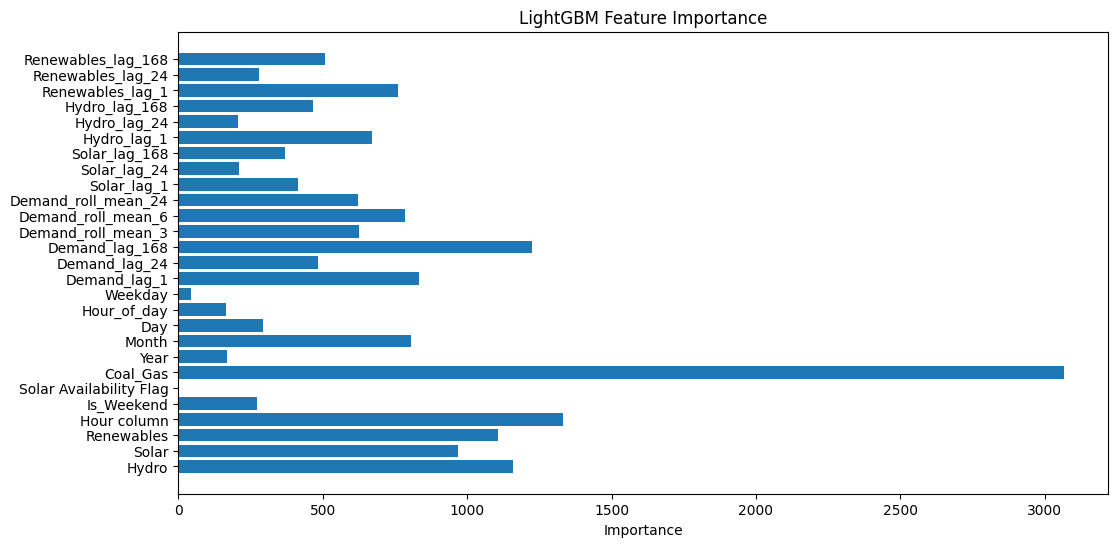

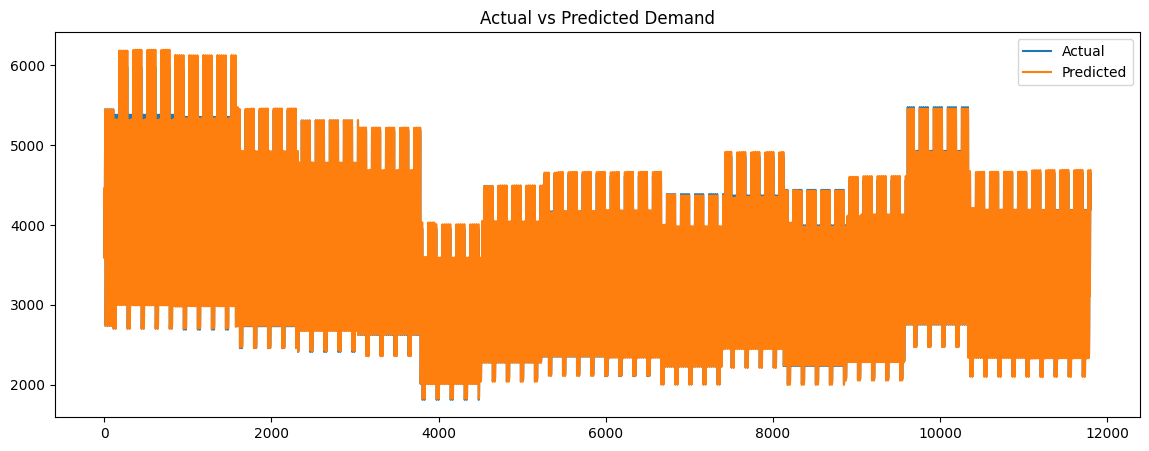

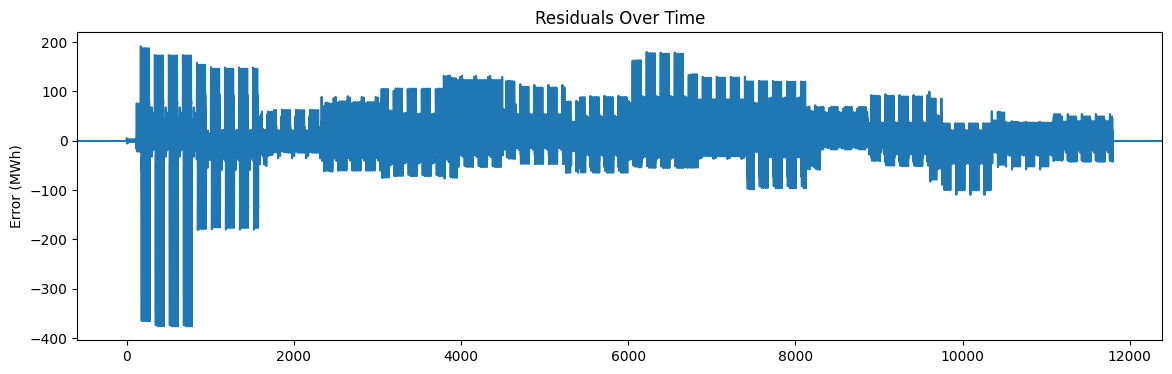

In [14]:
# -----------------------------
# Imports
# -----------------------------
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import lightgbm as lgb


# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv("haryana_hourly_generation_preprocessed.csv")

# Sort by time (assuming 'Year', 'Month', 'Day', 'Hour_of_day' exist)
df = df.sort_values(by=['Year', 'Month', 'Day', 'Hour_of_day']).reset_index(drop=True)

# -----------------------------
# Create lag features for Demand_MWh
# -----------------------------
lags = [1, 24, 168]  # 1 hour, 1 day, 1 week
for lag in lags:
    df[f'Demand_lag_{lag}'] = df['Demand_MWh'].shift(lag)

# -----------------------------
# Create rolling mean features for Demand_MWh
# -----------------------------
windows = [3, 6, 24]  # rolling windows in hours
for window in windows:
    df[f'Demand_roll_mean_{window}'] = df['Demand_MWh'].shift(1).rolling(window=window).mean()

# -----------------------------
# Optional: create lag features for renewables
# -----------------------------
for col in ['Solar', 'Hydro', 'Renewables']:
    for lag in lags:
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)

# Drop rows with NaN created by shift/rolling
df = df.dropna().reset_index(drop=True)

# -----------------------------
# Features and target
# -----------------------------
target = 'Demand_MWh'
drop_cols = ['Demand_MWh', 'Ramp Rate (change in demand)']  # drop target & derived feature
X = df.drop(columns=drop_cols)
y = df[target]

# -----------------------------
# Convert categorical columns to 'category' dtype
# -----------------------------
categorical_features = ['Is_Weekend', 'Weekday', 'Hour column', 'Solar Availability Flag']
for col in categorical_features:
    X[col] = X[col].astype('category')

# -----------------------------
# Time-based train-test split
# -----------------------------
train_size = 0.8
train_index = int(len(df) * train_size)

X_train, X_test = X.iloc[:train_index], X.iloc[train_index:]
y_train, y_test = y.iloc[:train_index], y.iloc[train_index:]

# -----------------------------
# Initialize and train LightGBM
# -----------------------------
model = LGBMRegressor(
    objective='regression',
    learning_rate=0.1,
    max_depth=6,
    num_leaves=31,
    n_estimators=1000,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse',
    categorical_feature=categorical_features,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)


# -----------------------------
# Predictions and evaluation
# -----------------------------
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n✅ LightGBM Results with Lag & Rolling Features:")
print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")

# -----------------------------
# Feature importance
# -----------------------------
feature_importances = model.feature_importances_
plt.figure(figsize=(12,6))
plt.barh(X.columns, feature_importances)
plt.xlabel("Importance")
plt.title("LightGBM Feature Importance")
plt.show()

plt.figure(figsize=(14,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Demand")
plt.show()

residuals = y_test.values - y_pred

plt.figure(figsize=(14,4))
plt.plot(residuals)
plt.axhline(0)
plt.title("Residuals Over Time")
plt.ylabel("Error (MWh)")
plt.show()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000365 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1356
[LightGBM] [Info] Number of data points in the train set: 50142, number of used features: 10
[LightGBM] [Info] Start training from score 2751.755209
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 49.7504	valid_0's l2: 2475.1
[200]	valid_0's rmse: 44.7723	valid_0's l2: 2004.56
[300]	valid_0's rmse: 43.0867	valid_0's l2: 1856.46
[400]	valid_0's rmse: 41.7407	valid_0's l2: 1742.28
[500]	valid_0's rmse: 40.7554	valid_0's l2: 1661
[600]	valid_0's rmse: 40.1018	valid_0's l2: 1608.16
[700]	valid_0's rmse: 39.646	valid_0's l2: 1571.81
[800]	valid_0's rmse: 39.2622	valid_0's l2: 1541.52
[900]	valid_0's rmse: 38.6489	valid_0's l2: 1493.74
[1000]	valid_0's rmse: 38.2451	valid_0's l2: 1462.69
Did not meet e

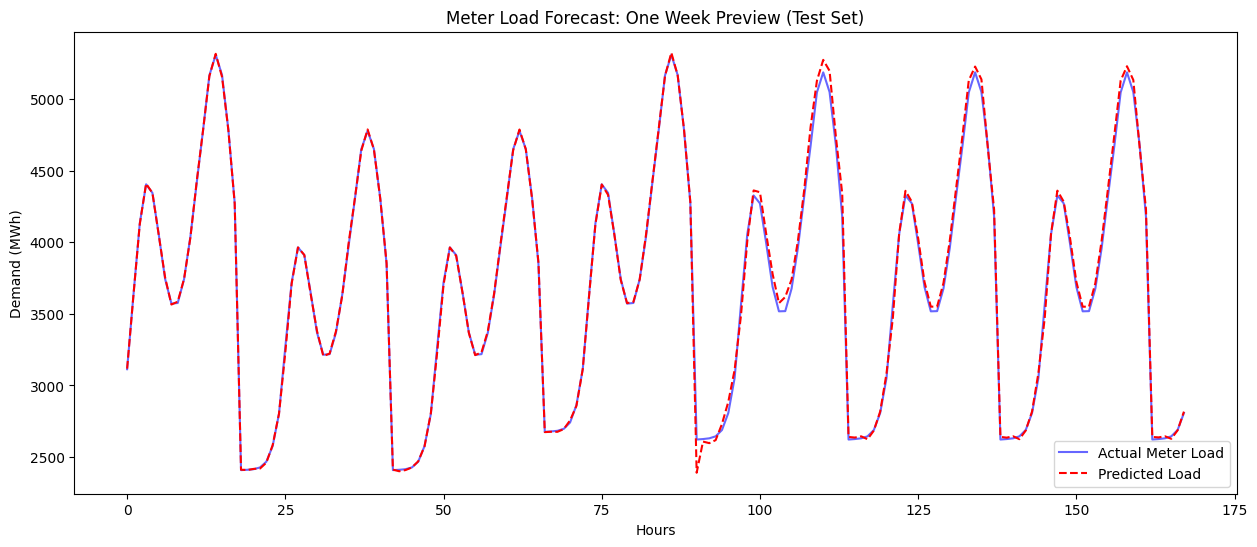

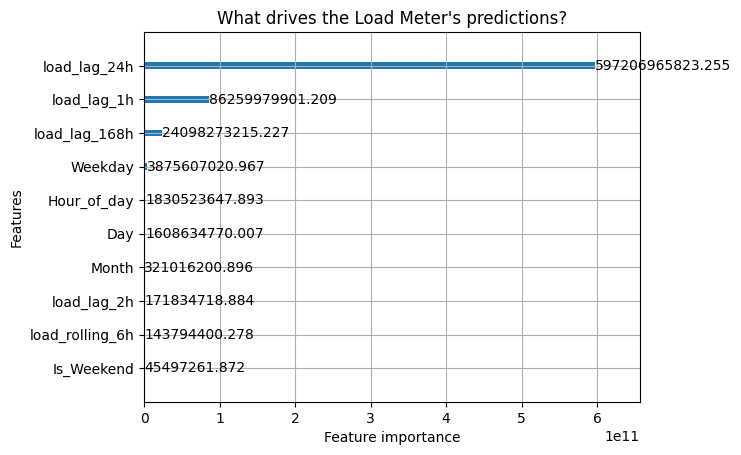

In [17]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# -----------------------------
# 1. LOAD & CLEAN
# -----------------------------
df = pd.read_csv("haryana_hourly_generation_preprocessed.csv")

# Ensure the data is in time-order
df = df.sort_values(by=['Year', 'Month', 'Day', 'Hour_of_day']).reset_index(drop=True)

# -----------------------------
# 2. FEATURE SELECTION (Load & Time Only)
# -----------------------------
# We create a 'clean' dataframe with only the target and calendar info
# Dropping all generation sources and derived "Ramp" columns
keep_cols = ['Demand_MWh', 'Hour_of_day', 'Weekday', 'Is_Weekend', 'Month', 'Day']
df_meter = df[keep_cols].copy()

# -----------------------------
# 3. HISTORY BUILDING (Lags)
# -----------------------------
# This is how the meter "remembers" the past to predict the future.
# lag_1: Load 1 hour ago (Short term momentum)
# lag_24: Load at this same time yesterday (Daily cycle)
# lag_168: Load at this same time last week (Weekly cycle)
lags = [1, 2, 24, 168]
for lag in lags:
    df_meter[f'load_lag_{lag}h'] = df_meter['Demand_MWh'].shift(lag)

# Rolling average of the last 6 hours (captures the current "session" trend)
df_meter['load_rolling_6h'] = df_meter['Demand_MWh'].shift(1).rolling(window=6).mean()

# Drop rows where we don't have enough history yet (NaNs from shifts)
df_meter = df_meter.dropna().reset_index(drop=True)

# -----------------------------
# 4. PREPARE X and Y
# -----------------------------
X = df_meter.drop(columns=['Demand_MWh'])
y = df_meter['Demand_MWh']

# Mark categorical variables so LightGBM handles them as 'patterns' not 'numbers'
cat_features = ['Hour_of_day', 'Weekday', 'Is_Weekend', 'Month']
for col in cat_features:
    X[col] = X[col].astype('category')

# -----------------------------
# 5. TIME-SERIES SPLIT
# -----------------------------
# We split by time (last 15% of data is for testing) to simulate a real future
split_idx = int(len(X) * 0.85)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# -----------------------------
# 6. TRAIN THE MODEL
# -----------------------------
# Adjusted parameters to prevent the "No splits" warning
model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,         # Standard complexity
    min_child_samples=20,  # Allows trees to grow naturally
    importance_type='gain',
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

# -----------------------------
# 7. RESULTS & EVALUATION
# -----------------------------
y_pred = model.predict(X_test)

print("\n📊 LOAD METER FORECAST RESULTS:")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f} MWh")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")

# -----------------------------
# 8. VISUALIZE
# -----------------------------
plt.figure(figsize=(15, 6))
plt.plot(y_test.values[:168], label='Actual Meter Load', color='blue', alpha=0.6)
plt.plot(y_pred[:168], label='Predicted Load', color='red', linestyle='--')
plt.title("Meter Load Forecast: One Week Preview (Test Set)")
plt.xlabel("Hours")
plt.ylabel("Demand (MWh)")
plt.legend()
plt.show()

# Show what the meter relies on most
lgb.plot_importance(model, max_num_features=10, importance_type='gain')
plt.title("What drives the Load Meter's predictions?")
plt.show()


--- ⚡ LEGIT 6-HOUR FORECAST RESULTS ---
Hour 1 Ahead -> R²: 0.9972 | MAE: 31.40 MWh
Hour 1 Ahead -> MAPE: 0.87%
Hour 2 Ahead -> R²: 0.9918 | MAE: 56.24 MWh
Hour 2 Ahead -> MAPE: 1.58%
Hour 3 Ahead -> R²: 0.9824 | MAE: 82.71 MWh
Hour 3 Ahead -> MAPE: 2.27%
Hour 4 Ahead -> R²: 0.9691 | MAE: 109.46 MWh
Hour 4 Ahead -> MAPE: 2.95%
Hour 5 Ahead -> R²: 0.9565 | MAE: 130.11 MWh
Hour 5 Ahead -> MAPE: 3.47%
Hour 6 Ahead -> R²: 0.9476 | MAE: 145.10 MWh
Hour 6 Ahead -> MAPE: 3.87%


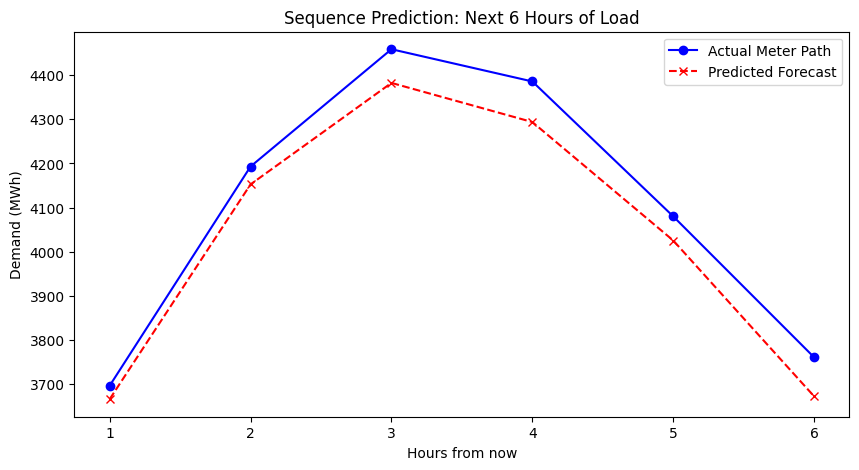

In [33]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import joblib

# ---------------------------------------------------------
# 1. DATA FIXING (The "Un-cooking" Phase)
# ---------------------------------------------------------
df = pd.read_csv("haryana_hourly_generation_preprocessed.csv")

# FIX 1: Sort including YEAR. This is why your previous models were failing.
# We also ensure no duplicate hours exist.
df = df.sort_values(by=['Year', 'Month', 'Day', 'Hour_of_day']).reset_index(drop=True)
df = df.drop_duplicates(subset=['Year', 'Month', 'Day', 'Hour_of_day'])

# FIX 2: Drop the columns you don't need for a load meter
drop_cols = ["Hydro", "Solar", "Renewables", "Solar Availability Flag", "Coal_Gas", "Ramp Rate (change in demand)"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# ---------------------------------------------------------
# 2. FEATURE ENGINEERING (Meter Vision Only)
# ---------------------------------------------------------
# Time Encoding
df["hour_sin"] = np.sin(2 * np.pi * df["Hour_of_day"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["Hour_of_day"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["Weekday"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["Weekday"] / 7)

# Meter Lags (Past behavior)
df['load_now'] = df['Demand_MWh']
df['load_lag_1h'] = df['Demand_MWh'].shift(1)
df['load_lag_24h'] = df['Demand_MWh'].shift(24) # Yesterday
df['load_lag_168h'] = df['Demand_MWh'].shift(168) # Last week

# ---------------------------------------------------------
# 3. MULTI-OUTPUT TARGETS (The next 6 hours)
# ---------------------------------------------------------
# We want to predict t+1, t+2, t+3, t+4, t+5, t+6
target_cols = []
for h in range(1, 7):
    col_name = f'target_{h}h'
    df[col_name] = df['Demand_MWh'].shift(-h)
    target_cols.append(col_name)

# ---------------------------------------------------------
# 4. FINAL SELECTION & CLEANING
# ---------------------------------------------------------
features = [
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'Weekday', 'Is_Weekend', 'Month',
    'load_now', 'load_lag_1h', 'load_lag_24h', 'load_lag_168h'
]

# Drop NaNs created by lagging and leading
df_clean = df.dropna(subset=features + target_cols).reset_index(drop=True)

X = df_clean[features]
Y = df_clean[target_cols]

# ---------------------------------------------------------
# 5. TIME-SERIES SPLIT
# ---------------------------------------------------------
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
Y_train, Y_test = Y.iloc[:split], Y.iloc[split:]

# ---------------------------------------------------------
# 6. TRAIN MULTI-OUTPUT MODEL
# ---------------------------------------------------------
# This trains 6 internal models, one for each future hour.
base_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=7,
    random_state=42
)

model = MultiOutputRegressor(base_model)
model.fit(X_train, Y_train)

# ---------------------------------------------------------
# 7. LEGIT EVALUATION
# ---------------------------------------------------------
Y_pred = model.predict(X_test)

print("\n--- ⚡ LEGIT 6-HOUR FORECAST RESULTS ---")
for i in range(6):
    r2 = r2_score(Y_test.iloc[:, i], Y_pred[:, i])
    mae = mean_absolute_error(Y_test.iloc[:, i], Y_pred[:, i])
    print(f"Hour {i+1} Ahead -> R²: {r2:.4f} | MAE: {mae:.2f} MWh")
    mape = mean_absolute_percentage_error(Y_test.iloc[:, i], Y_pred[:, i])
    print(f"Hour {i+1} Ahead -> MAPE: {mape:.2%}")

# ---------------------------------------------------------
# 8. VISUALIZE A REAL FORECAST STRING
# ---------------------------------------------------------
# This shows how the meter predicts the next 6 hours from a single point in time
sample_idx = 50 
plt.figure(figsize=(10, 5))
plt.plot(range(1, 7), Y_test.iloc[sample_idx], 'bo-', label='Actual Meter Path')
plt.plot(range(1, 7), Y_pred[sample_idx], 'rx--', label='Predicted Forecast')
plt.title("Sequence Prediction: Next 6 Hours of Load")
plt.xlabel("Hours from now")
plt.ylabel("Demand (MWh)")
plt.legend()
plt.show()

# Save for your project
joblib.dump(model, "fixed_load_meter_model.pkl")
from sklearn.metrics import mean_absolute_percentage_error


